In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# loading the data
try:
    df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print('keggel')
except FileNotFoundError:
    df = pd.read_csv("E:/Datasets/HR/HR-Employee-Attrition.csv")
    print('local')
df.head()

local


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Basic Checks
print(f'shape : {df.shape}\n')
print(f'shape : \n{df.isnull().sum()}\n')
print(f'duplicated : {df.duplicated().sum()}\n')
print({df.info()})

shape : (1470, 35)

shape : 
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurr

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
df.describe(include=['O']).transpose()

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


### Exploratory Data Analysis

In [ ]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html("eda_report.html")

### Insights
#### Arittion columns states that our data is imbalanced.

In [6]:
# catagorical columns
data1 = df[['Attrition', 'BusinessTravel', 'Department', 'EducationField',
              'Gender', 'JobRole', 'MaritalStatus', 'OverTime']]
data1.head()

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No


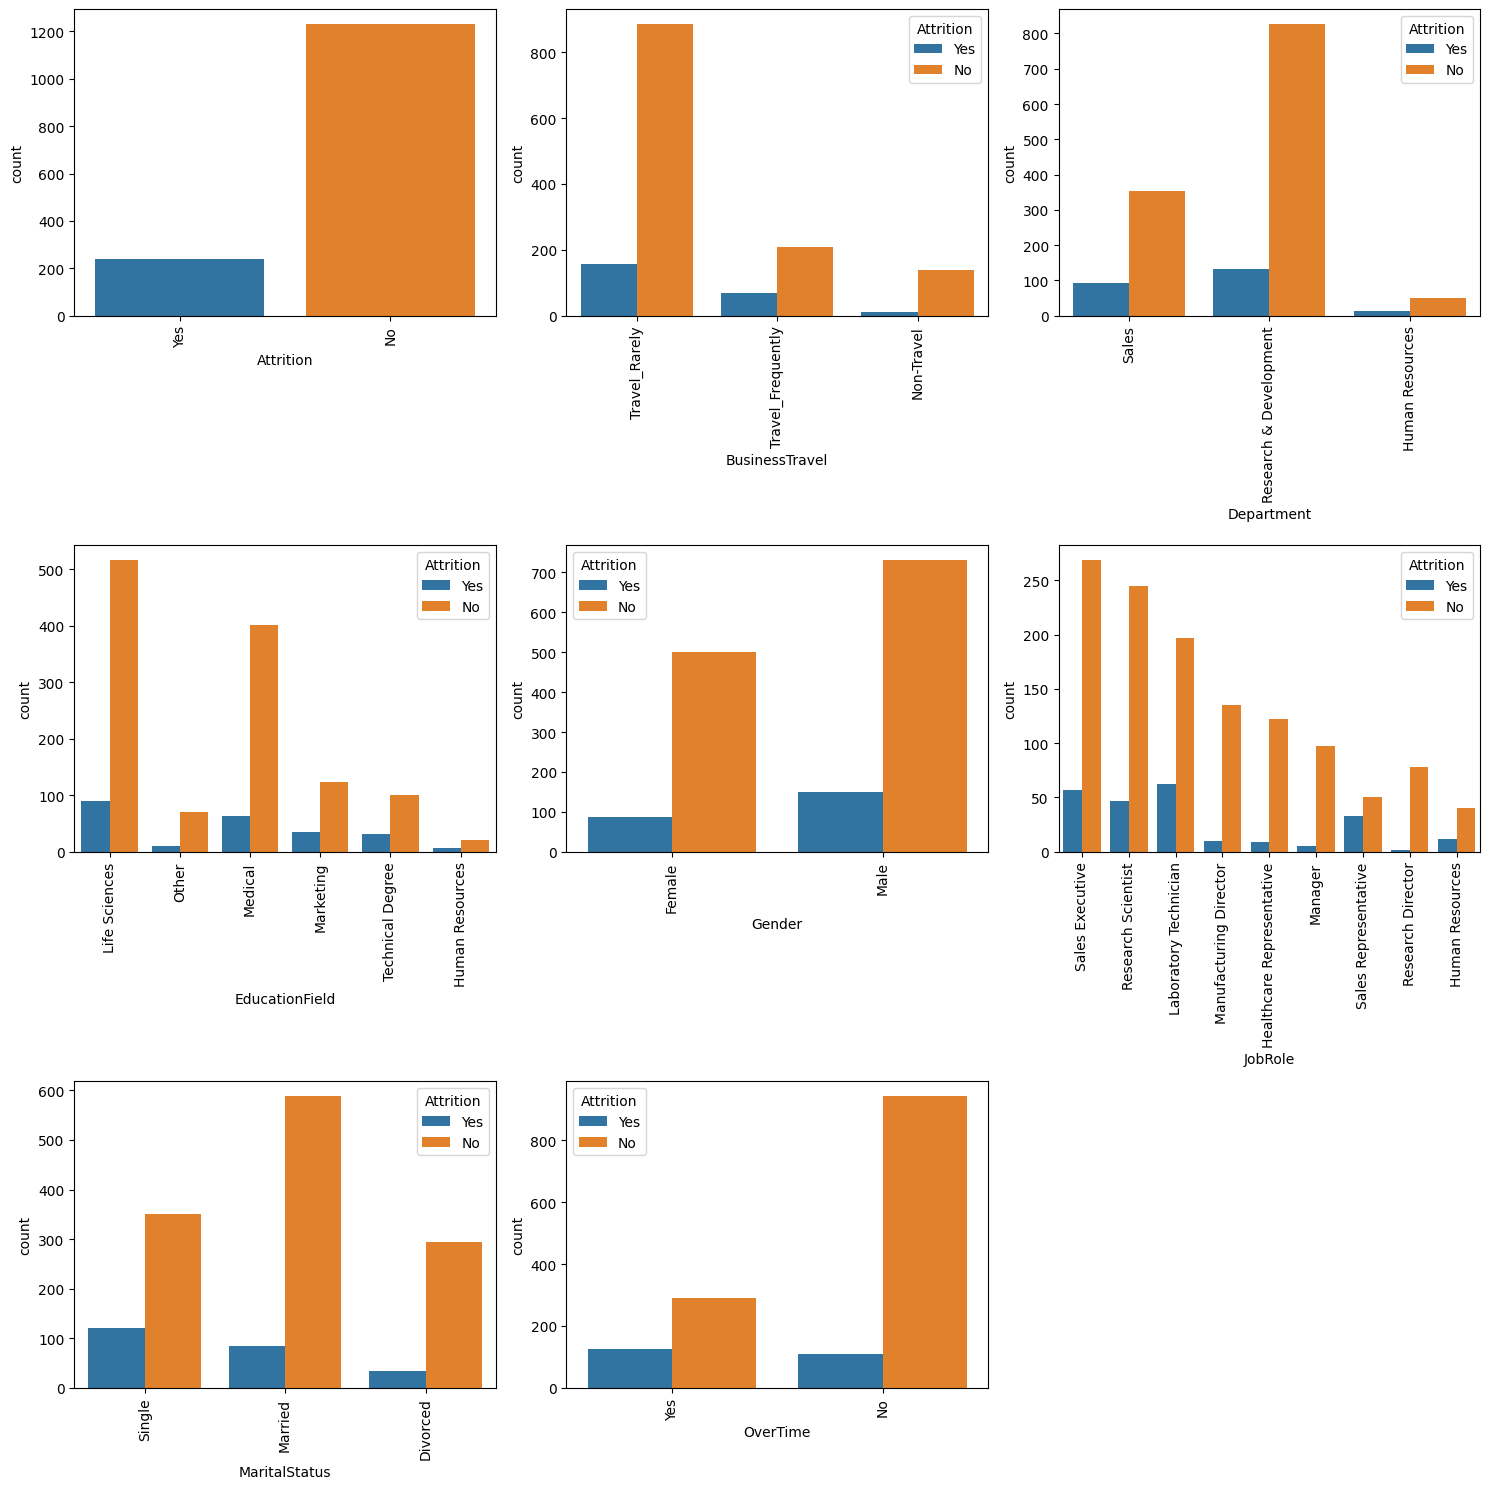

In [7]:
n = 1
plt.figure(figsize=(15, 15))
for i in data1.columns:
    if n <= len(data1.columns):
        ax = plt.subplot(3, 3, n)
        sns.countplot(data=data1, x=i, hue='Attrition')
        plt.xticks(rotation=90)
    n += 1
plt.tight_layout()
plt.show()

### Insights
#### Attrition Distribution : The majority of employees stay with the company, but a significant minority leave. This class imbalance should be considered during model training and evaluation.
#### BusinessTravel vs Attrition : Employees who travel frequently show higher attrition compared to those who travel rarely or not at all. Increased travel appears to contribute to burnout and higher turnover.
#### Department vs Attrition : The Sales department experiences higher attrition compared to Research & Development and Human Resources, indicating higher pressure or lower satisfaction in sales roles.
#### EducationField vs Attrition : Employees from Life Sciences and Medical backgrounds show relatively higher attrition in absolute numbers, while those from Technical Degree and Other fields also exhibit notable attrition, suggesting education background may influence retention patterns.
#### Gender vs Attrition : Attrition is observed in both genders, with males showing slightly higher attrition counts. However, the difference is not extreme, indicating gender alone is not a strong determinant of attrition.
#### JobRole vs Attrition : Sales Executives and Laboratory Technicians show higher attrition counts compared to other roles. Sales Representatives also exhibit relatively high turnover, highlighting role-specific stress and job nature as key factors.
#### MaritalStatus vs Attrition : Single employees show higher attrition compared to married and divorced employees. This suggests unmarried employees may have higher mobility and are more likely to switch jobs.
#### OverTime vs Attrition : Employees who work overtime have significantly higher attrition compared to those who do not. Overtime appears to be one of the strongest indicators of employee turnover.

In [8]:
data2 = df[['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
     'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
            'TrainingTimesLastYear', 'WorkLifeBalance']]

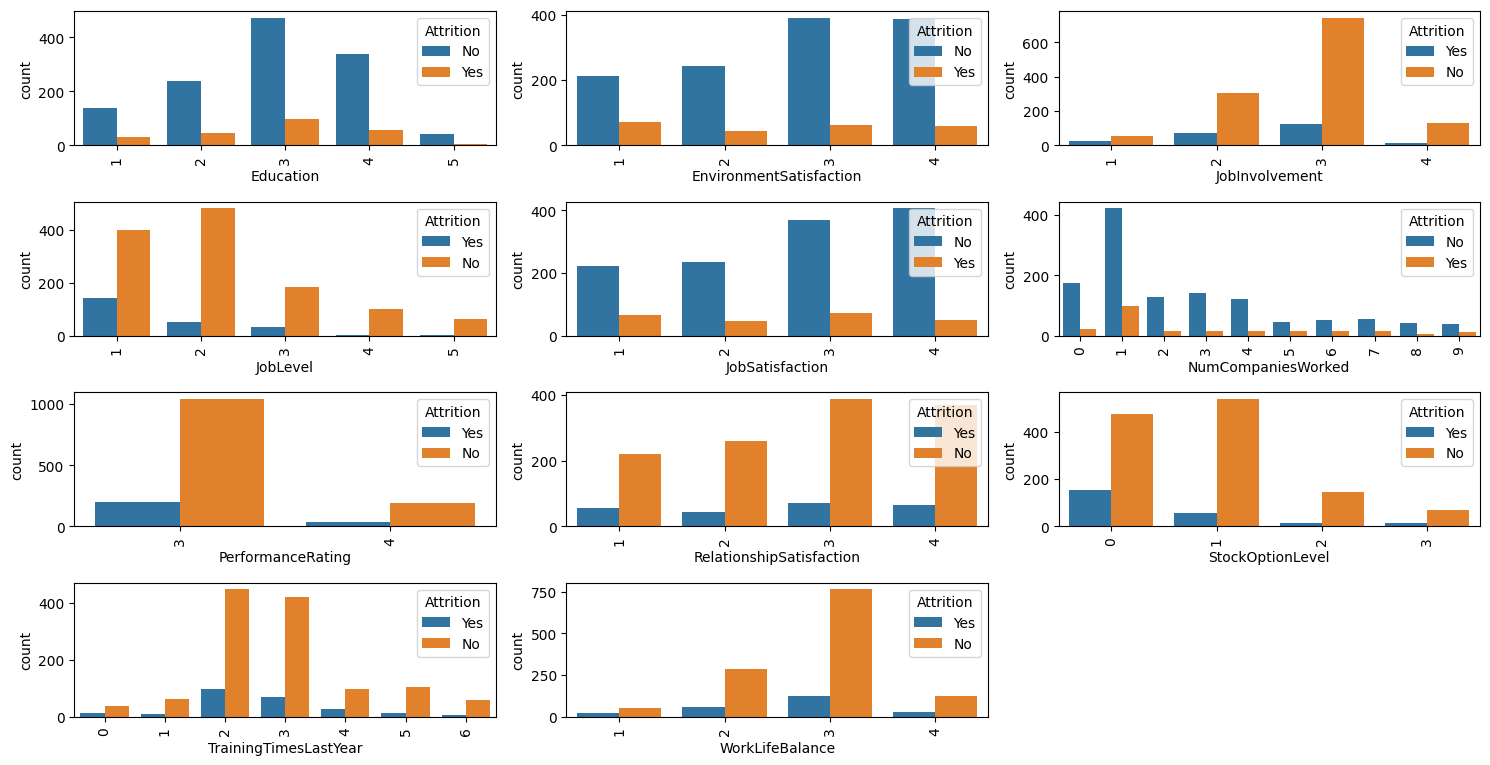

In [9]:
n = 1
plt.figure(figsize=(15, 15))
for i in data2.columns:
    if n <= len(data2.columns):
        ax = plt.subplot(8, 3, n)
        sns.countplot(data=data2, x=i, hue=df['Attrition'])
        plt.xticks(rotation=90)
    n += 1
plt.tight_layout()
plt.show()

### Insights
#### Employees with low Job Involvement (1–2) show significantly higher attrition compared to those with high involvement.
#### Employees at lower Job Levels (Level 1–2) are leaving the company more than senior-level employees.
#### Employees with low Job Satisfaction (1–2) have a much higher likelihood of attrition than satisfied employees.
#### Employees who have worked in fewer companies (0–2 previous companies) show higher attrition, indicating early-career instability.
#### Employees with lower Relationship Satisfaction (1–2) tend to leave more compared to those with better workplace relationships.
#### Employees with no or low Stock Options (0–1) have higher attrition than those with higher stock option levels.
#### Employees with poor Work-Life Balance (1–2) are more likely to leave compared to those with better balance.
#### Employees with lower Environment Satisfaction (1–2) show higher attrition than those satisfied with their work environment.

In [10]:
data3 = df[['Age',
              'DailyRate',
              'DistanceFromHome',
              'HourlyRate',
              'MonthlyIncome',
              'MonthlyRate',
              'PercentSalaryHike',
              'TotalWorkingYears',
              'YearsAtCompany',
              'YearsInCurrentRole',
              'YearsSinceLastPromotion',
              'YearsWithCurrManager']]

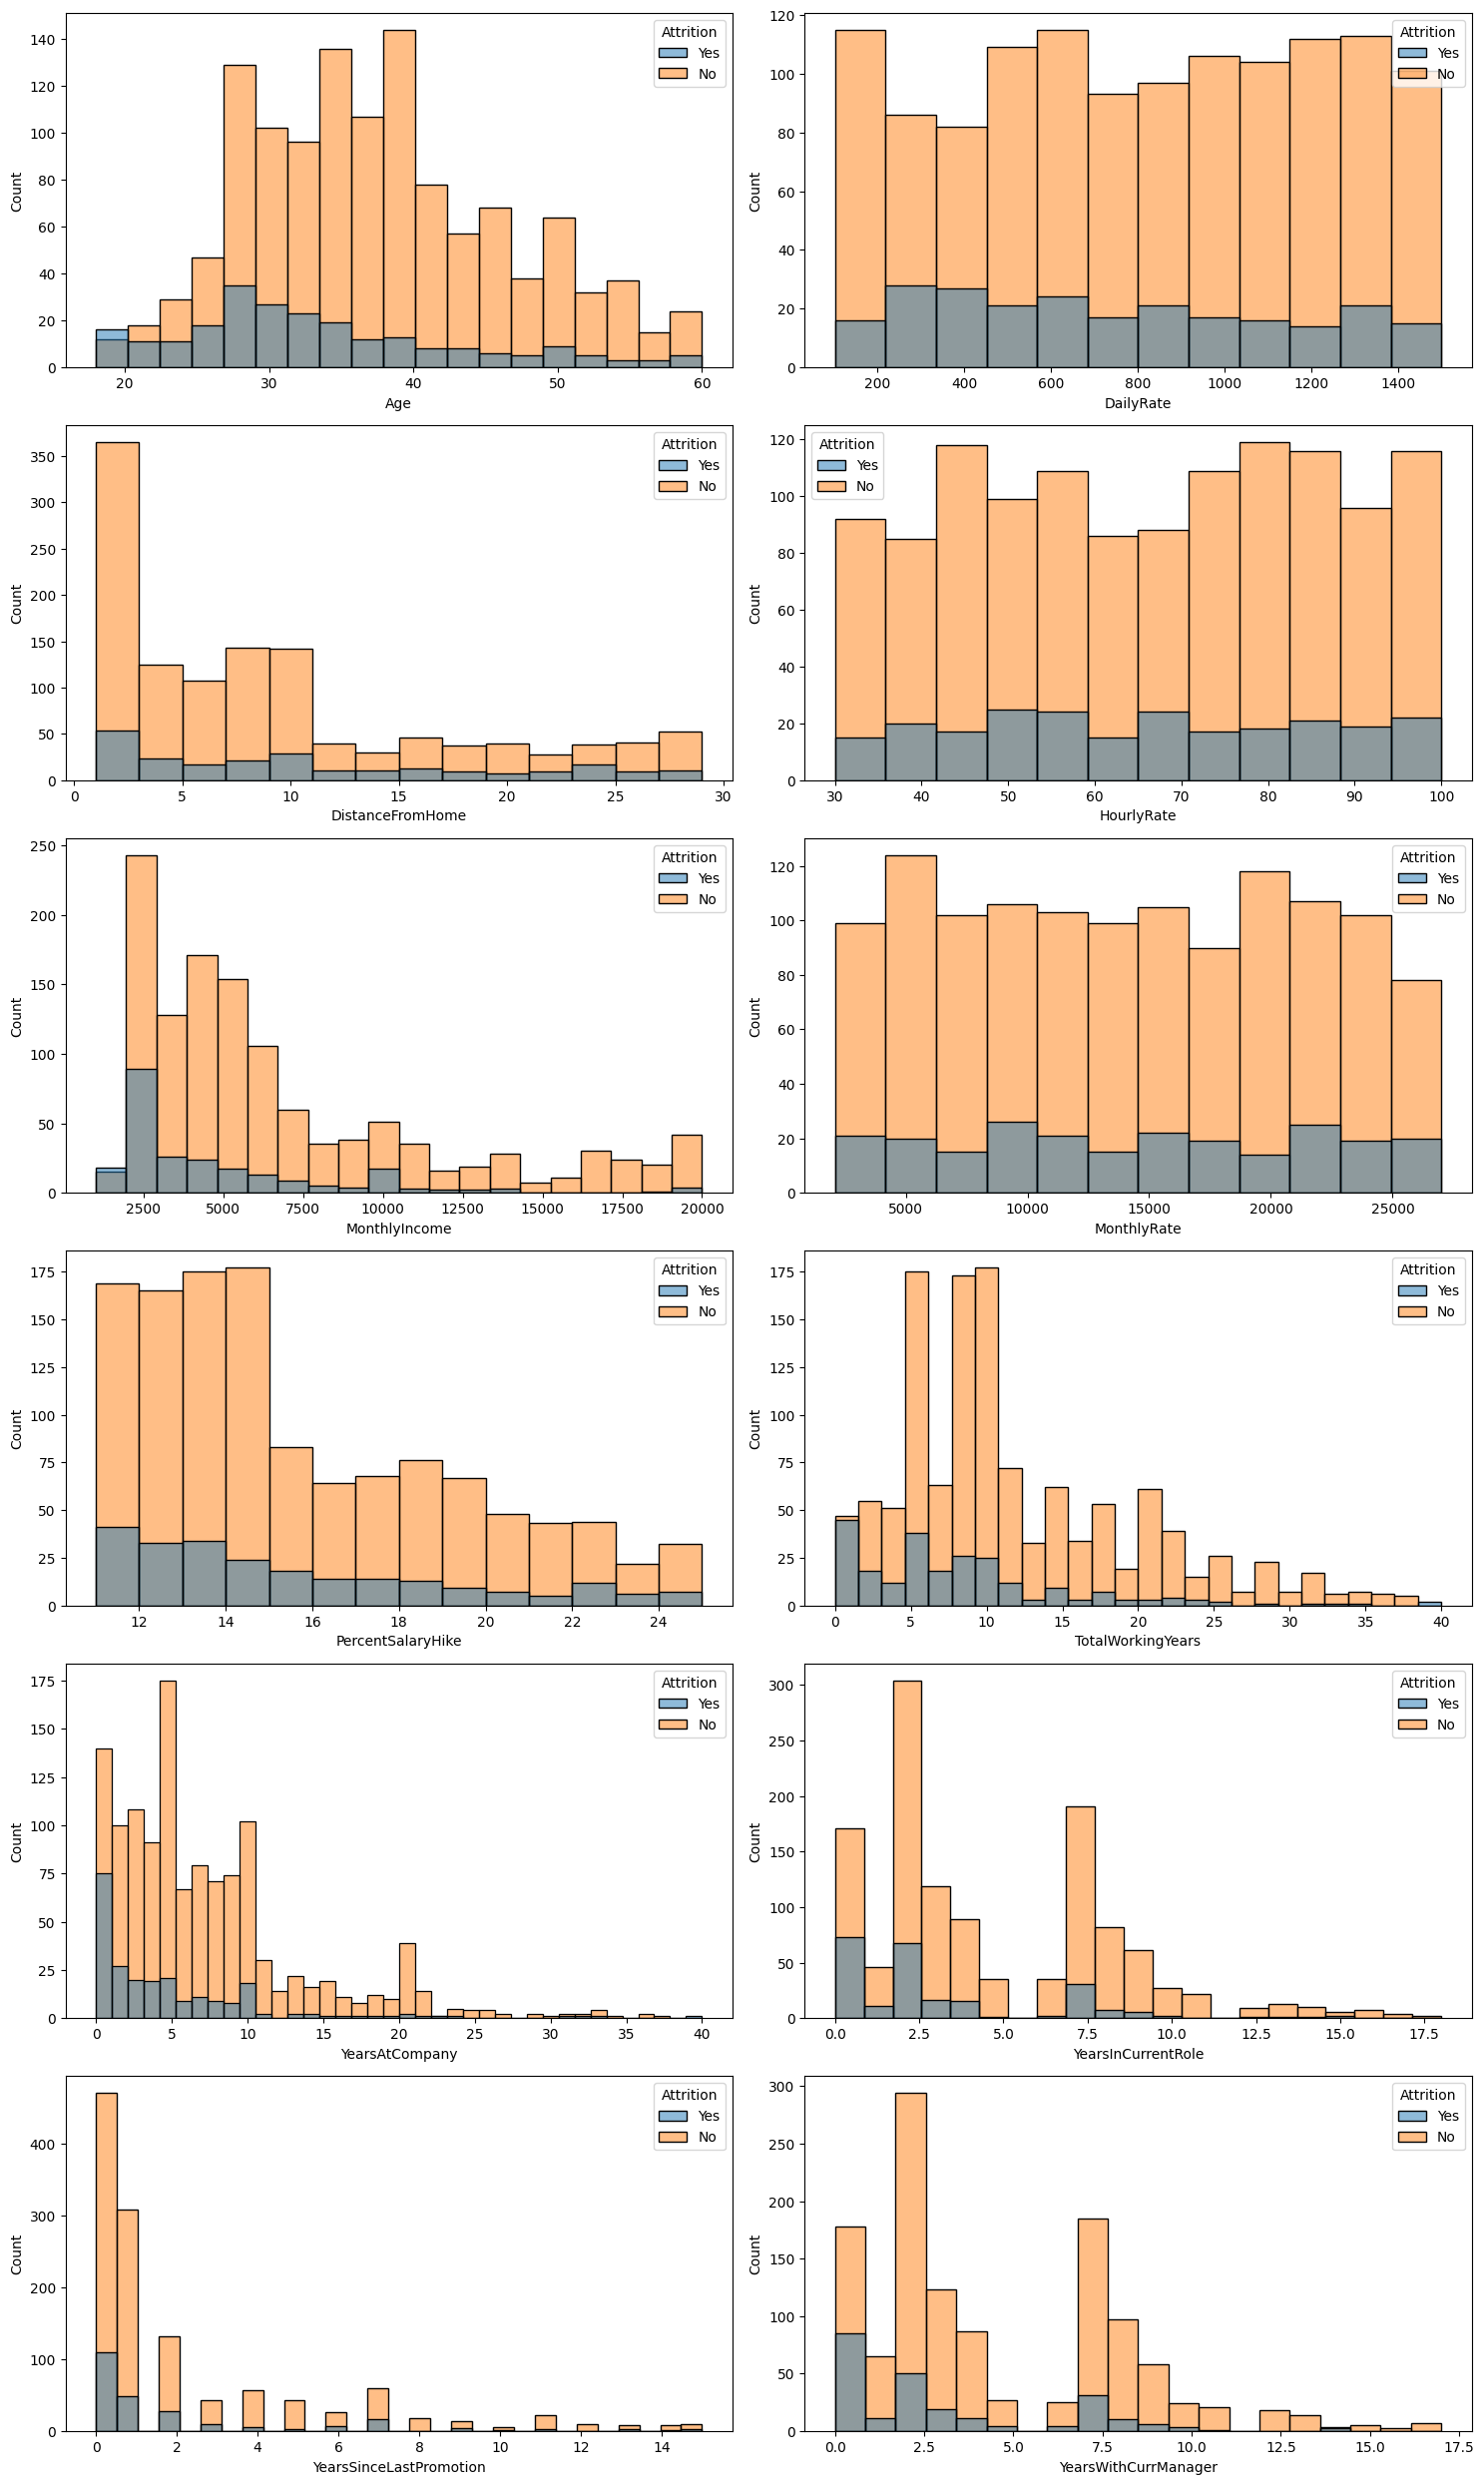

In [11]:
n = 1
plt.figure(figsize=(15, 25))
for i in data3.columns:
    if n <= len(data3.columns):
        ax = plt.subplot(6, 2, n)
        sns.histplot(x=data3[i], hue=df['Attrition'])
    n += 1
plt.tight_layout()
plt.show()

In [12]:
### label encodings
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [13]:
df['Attrition'] = df['Attrition'].map({'Yes' : 1, "No" : 0})

In [14]:
df['BusinessTravel'] = df['BusinessTravel'].map({'Travel_Rarely' : 1, 'Travel_Frequently' : 2, 'Non-Travel': 0})

In [15]:
df['Department'] = df['Department'].map({'Sales' : 0, 'Research & Development' : 2, 'Human Resources': 1})

In [16]:
df['EducationField'] = df['EducationField'].map({'Life Sciences' : 5, 'Other': 0, 'Medical': 4, 'Marketing' : 2, 'Technical Degree' : 3,
                                                 'Human Resources' : 1})

In [17]:
df['Gender'] = df['Gender'].map({'Female' : 0, 'Male' : 1})

In [18]:
df['JobRole'] = df['JobRole'].map({'Sales Executive' : 5, 'Research Scientist' : 6, 'Laboratory Technician' : 2,
                                  'Manufacturing Director' : 3, 'Healthcare Representative' : 2, 'Manager' : 1,
                                  'Sales Representative' : 4, 'Research Director' : 7, 'Human Resources' : 0})

In [19]:
df['MaritalStatus'] = df['MaritalStatus'].map({'Single' : 0, 'Married' : 1, 'Divorced' : 2})

In [20]:
df['OverTime'] = df['OverTime'].map({'Yes' : 1, 'No' : 0})

In [21]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.00,0.0,0.00,1.0
BusinessTravel,1470.0,1.086395,0.532170,0.0,1.00,1.0,1.00,2.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
Department,1470.0,1.350340,0.913768,0.0,0.00,2.0,2.00,2.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EducationField,1470.0,3.827891,1.401511,0.0,3.00,4.0,5.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [22]:
# feature selection and droping unnecessary columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

In [23]:
data3.corr()

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.024287,0.497855,0.028051,0.003634,0.680381,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,0.023381,0.007707,-0.032182,0.022704,0.014515,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.031131,-0.017014,0.027473,0.040235,0.004628,0.009508,0.018845,0.010029,0.014406
HourlyRate,0.024287,0.023381,0.031131,1.000000,-0.015794,-0.015297,-0.009062,-0.002334,-0.019582,-0.024106,-0.026716,-0.020123
MonthlyIncome,0.497855,0.007707,-0.017014,-0.015794,1.000000,0.034814,-0.027269,0.772893,0.514285,0.363818,0.344978,0.344079
MonthlyRate,0.028051,-0.032182,0.027473,-0.015297,0.034814,1.000000,-0.006429,0.026442,-0.023655,-0.012815,0.001567,-0.036746
PercentSalaryHike,0.003634,0.022704,0.040235,-0.009062,-0.027269,-0.006429,1.000000,-0.020608,-0.035991,-0.001520,-0.022154,-0.011985
TotalWorkingYears,0.680381,0.014515,0.004628,-0.002334,0.772893,0.026442,-0.020608,1.000000,0.628133,0.460365,0.404858,0.459188
YearsAtCompany,0.311309,-0.034055,0.009508,-0.019582,0.514285,-0.023655,-0.035991,0.628133,1.000000,0.758754,0.618409,0.769212
YearsInCurrentRole,0.212901,0.009932,0.018845,-0.024106,0.363818,-0.012815,-0.001520,0.460365,0.758754,1.000000,0.548056,0.714365


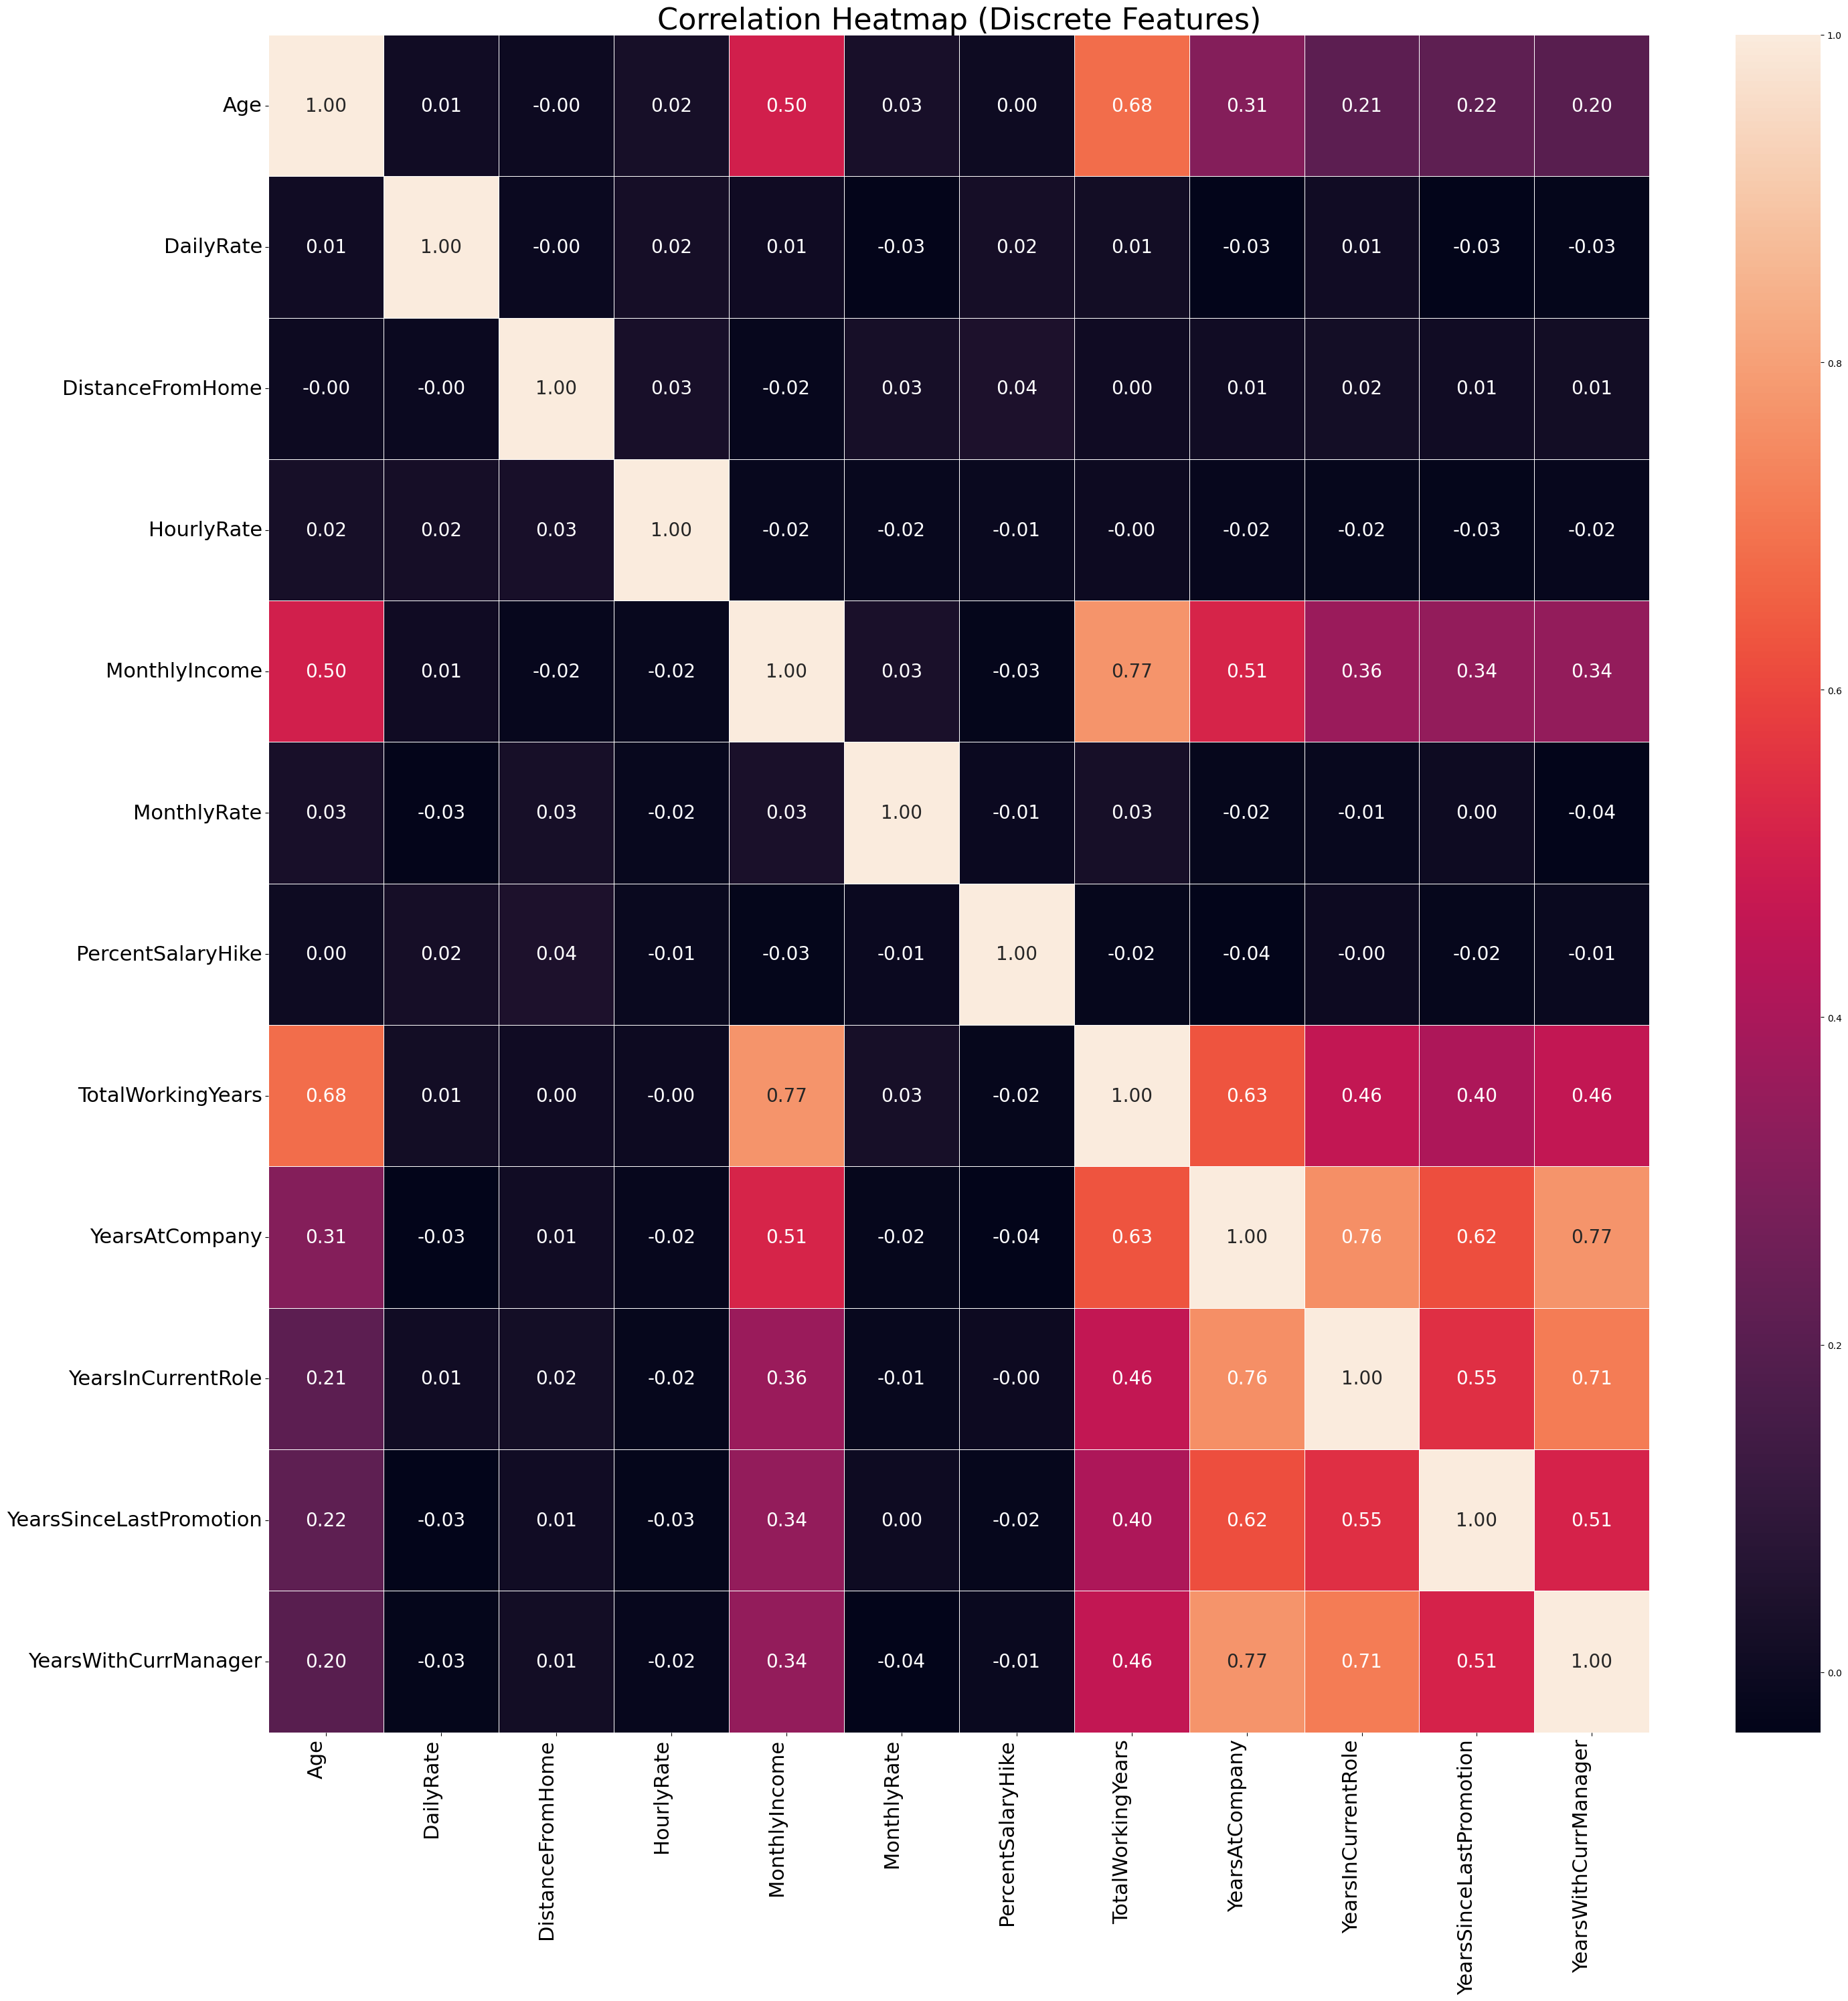

In [24]:
plt.figure(figsize=(30, 30))
sns.heatmap(data= data3.corr(), annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 20})
plt.title("Correlation Heatmap (Discrete Features)", fontsize=32)
plt.xticks(rotation=90, ha="right", fontsize=22)
plt.yticks(rotation=0, ha="right", fontsize=22)

plt.tight_layout()
plt.show()

### Decision Tree Model

In [25]:
x = df.drop(columns='Attrition')
y = df['Attrition']

In [26]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

In [27]:
# Balcancing The Data
from collections import Counter
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
print(Counter(y_train))
x_sm, y_sm = sm.fit_resample(x_train, y_train)
print(Counter(y_sm))

Counter({0: 924, 1: 178})
Counter({0: 924, 1: 924})


In [28]:
# Model Creation
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=3, splitter='random', random_state=42)
dt.fit(x_sm, y_sm)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [29]:
# Prediction
y_pred1 = dt.predict(x_test)

In [30]:
# model Evaluation
from sklearn.metrics import accuracy_score, classification_report, f1_score
print(f'Accuracy of the model is : {accuracy_score(y_test, y_pred1)}\n')
print(f'f1 score of the model is : {f1_score(y_test, y_pred1)}\n')
print(f'classification report of the model is : \n{classification_report(y_test, y_pred1)}')


Accuracy of the model is : 0.75

f1 score of the model is : 0.2923076923076923

classification report of the model is : 
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       309
           1       0.27      0.32      0.29        59

    accuracy                           0.75       368
   macro avg       0.57      0.58      0.57       368
weighted avg       0.77      0.75      0.76       368



### Conclusion
#### The Decision Tree model achieved performance on the employee attrition dataset, with an overall accuracy of ~75% and F1 score of ~29%

### Trying Random forest Model for the Data

In [31]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10, min_samples_split=20, random_state=42)
rfc.fit(x_sm, y_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [32]:
y_pred2 = rfc.predict(x_test)

In [33]:
print(f'Accuracy of the model is : {accuracy_score(y_test, y_pred2)}\n')
print(f'f1 score of the model is : {f1_score(y_test, y_pred2)}\n')
print(f'classification report of the model is : \n{classification_report(y_test, y_pred2)}')


Accuracy of the model is : 0.7989130434782609

f1 score of the model is : 0.39344262295081966

classification report of the model is : 
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       309
           1       0.38      0.41      0.39        59

    accuracy                           0.80       368
   macro avg       0.63      0.64      0.64       368
weighted avg       0.80      0.80      0.80       368



### Conclusion
#### The Random Tree classifier achieved performance on the employee attrition dataset, with an overall accuracy of ~79% and F1 score of ~39%

### Hyperparameter Tuning

In [34]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(start=200, stop= 2000, num=10)]
max_features = ['log2', 'sqrt']
max_depth = [int(x) for x in np.linspace(start=10, stop=110, num=11)]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

random_grid = {'n_estimators' : n_estimators, 'max_features' : max_features, 'max_depth' : max_depth,
               'min_samples_split' : min_samples_split, 'min_samples_leaf' : min_samples_leaf}

In [35]:
rf_clf1 = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_cv = RandomizedSearchCV(estimator= rf_clf1, scoring='f1', param_distributions=random_grid, n_iter=100, cv= 3,
                           verbose=2, random_state=42, n_jobs=-1)

In [36]:
rf_cv.fit(x_train, y_train)
df_best_param = rf_cv.best_params_
print(f'best parm : {df_best_param}')

Fitting 3 folds for each of 100 candidates, totalling 300 fits
best parm : {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 100}


In [37]:
rfc_hypertuned = RandomForestClassifier(n_estimators= 400, min_samples_split= 2, min_samples_leaf= 4, 
                                        max_features= 'log2', max_depth= 100, random_state=42, class_weight='balanced')
rfc_hypertuned.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [38]:
y_pred3= rfc_hypertuned.predict(x_test)

In [39]:
print(f'Accuracy of the model is : {accuracy_score(y_test, y_pred3)}\n')
print(f'f1 score of the model is : {f1_score(y_test, y_pred3)}\n')
print(f'classification report of the model is : \n{classification_report(y_test, y_pred3)}')


Accuracy of the model is : 0.8260869565217391

f1 score of the model is : 0.2727272727272727

classification report of the model is : 
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       309
           1       0.41      0.20      0.27        59

    accuracy                           0.83       368
   macro avg       0.64      0.57      0.59       368
weighted avg       0.79      0.83      0.80       368



### Conclusion
#### The Random Tree classifier achieved performance on the employee attrition dataset, with an overall accuracy of ~82% and F1 score of ~27%